#Titanic Survival Prediction Using Machine Learning

Objective:
To predict whether a passenger survived the Titanic disaster using machine learning techniques and to understand the complete ML workflow including data preprocessing, exploratory data analysis, model training, and evaluation.

In [36]:
#Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [37]:
#Loading Titanic dataset

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
#Display basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [39]:
#Check Null Values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing Fare values with median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [41]:
# Verify missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [42]:
# Convert categorical data into numerical form

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df['Embarked'] = encoder.fit_transform(df['Embarked'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [43]:
# Drop columns not useful for prediction

df.drop(['PassengerId',
         'Name',
         'Ticket',
         'Cabin'],
         axis=1,
         inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


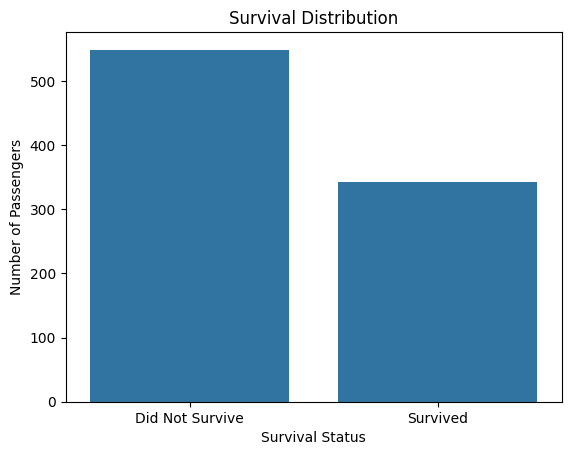

In [44]:
# Count survived and not survived passengers

df['Survival_Status'] = df['Survived'].map({
    0: 'Did Not Survive',
    1: 'Survived'
})

sns.countplot(x='Survival_Status', data=df)

plt.title("Survival Distribution")

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

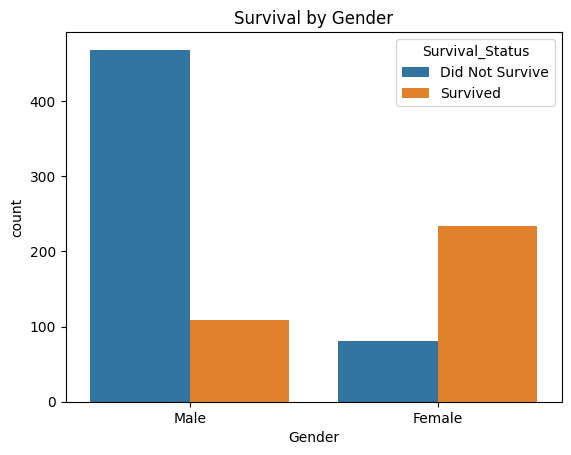

In [45]:
# Compare survival based on gender

df['Gender'] = df['Sex'].map({0: 'Female', 1: 'Male'})
df['Survival_Status'] = df['Survived'].map({
    0: 'Did Not Survive',
    1: 'Survived'
})

sns.countplot(
    x='Gender',
    hue='Survival_Status',
    data=df
)

plt.title("Survival by Gender")
plt.show()

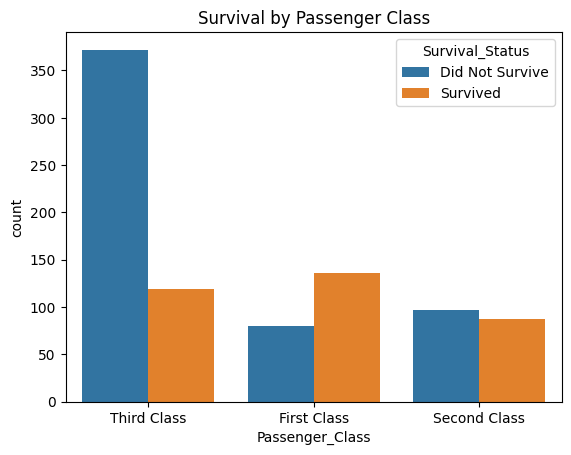

In [46]:
# Compare survival based on class

df['Passenger_Class'] = df['Pclass'].map({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})

sns.countplot(
    x='Passenger_Class',
    hue='Survival_Status',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

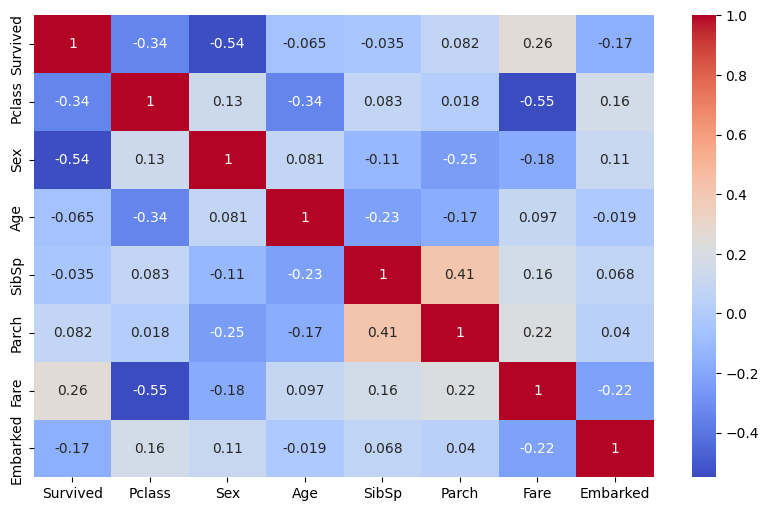

In [47]:
# Correlation between numerical variables

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [48]:
# Features (input)

X = df.drop([
    'Survived',
    'Gender',
    'Survival_Status',
    'Passenger_Class'
], axis=1)

# Target (output)

y = df['Survived']

In [49]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
# Create Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [51]:
# Predict survival for test data

y_pred = model.predict(X_test)

# Display first 10 predictions

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [52]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8100558659217877


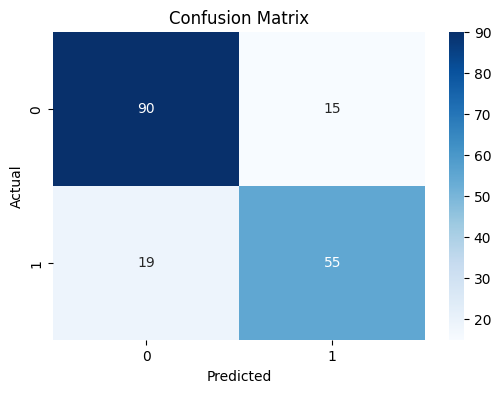

In [53]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [54]:
# Display detailed performance metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Conclusion

The Titanic Survival Prediction project was successfully implemented using the Logistic Regression algorithm. The dataset was preprocessed by handling missing values, converting categorical variables into numerical form, and removing unnecessary columns. Exploratory Data Analysis (EDA) was performed to understand the relationships between different features and passenger survival.

The model was trained and tested using an 80:20 train-test split. The Logistic Regression model achieved an accuracy of 81%, indicating good predictive performance. The analysis showed that factors such as passenger class, gender, and age had a significant influence on survival chances.

This project helped in understanding the complete machine learning workflow, including data preprocessing, exploratory analysis, model building, prediction, and evaluation.

# Future Scope

The performance of the Titanic Survival Prediction model can be improved by using advanced machine learning algorithms such as Random Forest, Decision Tree, and XGBoost. Additional feature engineering techniques and hyperparameter tuning can also be applied to increase prediction accuracy. Furthermore, larger datasets and more passenger-related information can be incorporated to build a more robust and reliable prediction system.